In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)


Dataset Shape: (20640, 8)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Baseline R2 Score:", r2_score(y_test, y_pred))

Baseline RMSE: 0.7037294974840077
Baseline R2 Score: 0.622075845135081


# 5. Important Hyperparameters


* max_depth          -> controls tree depth (overfitting control)
* min_samples_split  -> min samples required to split node
* min_samples_leaf   -> min samples required at leaf node
* max_features       -> number of features to consider at split
* max_leaf_nodes     -> limits total leaf nodes


   max_depth      RMSE
0        2.0  0.868483
1        4.0  0.764464
2        6.0  0.705184
3       10.0  0.644568
4        NaN  0.703729


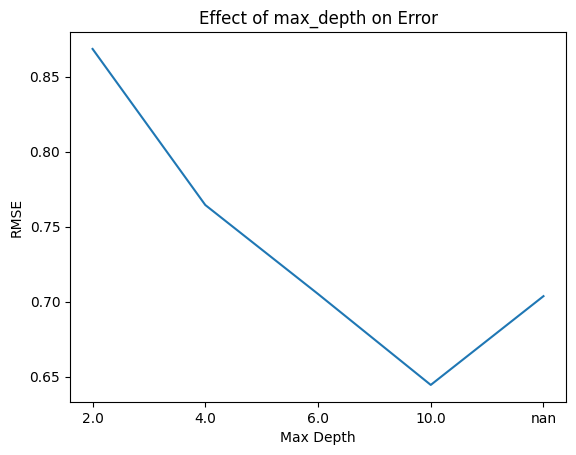

In [6]:
depths = [2, 4, 6, 10, None]
results = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append((d, rmse))

df_results = pd.DataFrame(results, columns=["max_depth", "RMSE"])
print(df_results)

plt.plot(df_results["max_depth"].astype(str), df_results["RMSE"])
plt.xlabel("Max Depth")
plt.ylabel("RMSE")
plt.title("Effect of max_depth on Error")
plt.show()

In [7]:
param_grid = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [8]:
y_pred_best = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("Tuned RMSE:", rmse)
print("Tuned R2 Score:", r2)

Tuned RMSE: 0.6390654005312799
Tuned R2 Score: 0.6883380738855668


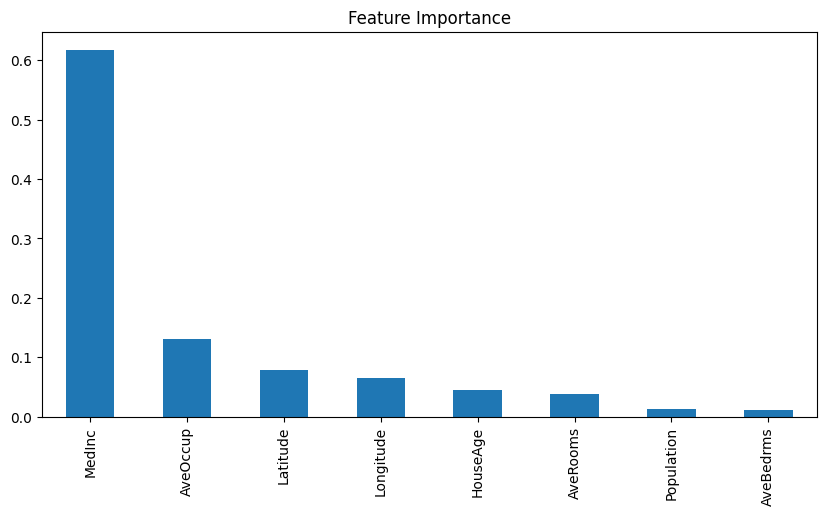

In [9]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()


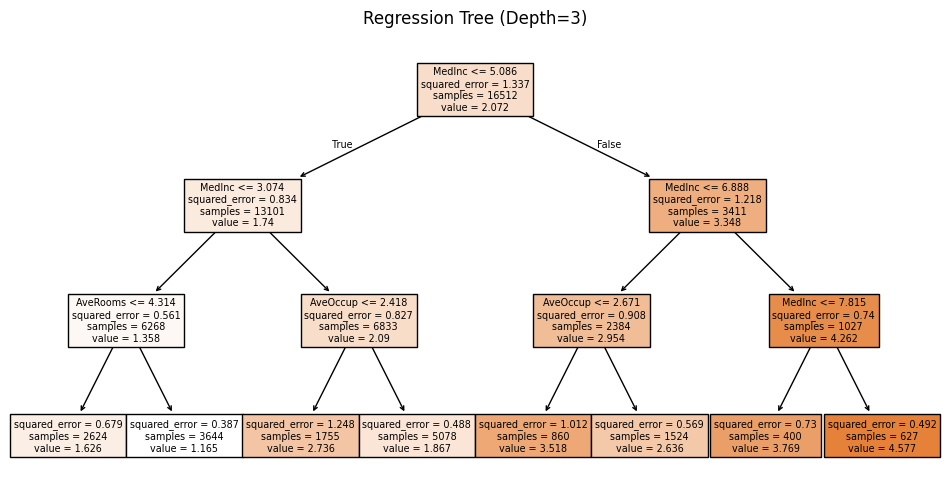

In [10]:
small_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
small_tree.fit(X_train, y_train)

plt.figure(figsize=(12,6))
plot_tree(small_tree, filled=True, feature_names=X.columns)
plt.title("Regression Tree (Depth=3)")
plt.show()